# Анализ экспериментов музейного комплекса

Загрузка и визуализация результатов: основной датасет `results.csv`, при наличии — дополнительно `ai_results.csv` (эксперименты с ИИ-управлением). Объединённый датафрейм помечается столбцом `isAiPowered`.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (10, 5)

results_path = Path('results.csv')
ai_path = Path('ai_results.csv')

df_base = pd.read_csv(results_path)
if 'investMinProb' not in df_base.columns:
    df_base['investMinProb'] = 0.1
df_base['isAiPowered'] = 0

if ai_path.exists():
    df_ai = pd.read_csv(ai_path)
    if 'investMinProb' not in df_ai.columns:
        if 'numVisitors' in df_ai.columns:
            df_ai.insert(df_ai.columns.get_loc('numVisitors'), 'investMinProb', 0.0)
        else:
            df_ai['investMinProb'] = 0.0
    df_ai['isAiPowered'] = 1
    df = pd.concat([df_base, df_ai], ignore_index=True)
    print(f'Загружено {len(df_base)} строк из results.csv и {len(df_ai)} из ai_results.csv, всего {len(df)}.')
else:
    df = df_base
    print(f'Файл ai_results.csv не найден — только results.csv ({len(df)} строк).')

infra_cols = [
    'finalMobileNetwork', 'finalPaymentSystem', 'finalTransportAccess',
    'finalInternetQuality', 'finalNavigationAccess', 'finalServiceAvailability',
]
df['finalInfrastructure'] = df[infra_cols].mean(axis=1)

print('isAiPowered:', df['isAiPowered'].value_counts().to_dict())
df.head()

Загружено 288 строк из results.csv и 8 из ai_results.csv, всего 296.
isAiPowered: {0: 288, 1: 8}


,museumCapacity,hotelCapacity,ticketPrice,hotelPrice,monthlyExpenditures,investMinProb,numVisitors,maxDays,totalVisits,totalHotelStays,...,finalBudget,finalMobileNetwork,finalPaymentSystem,finalTransportAccess,finalInternetQuality,finalNavigationAccess,finalServiceAvailability,finalAvgReview,isAiPowered,finalInfrastructure
0,10,5,20,30,5000,0.1,65,365,894,272,...,-28960.0,36.60,36.60,39.05,39.05,39.05,39.05,14.48,0,38.233333
1,10,5,20,30,5000,0.1,65,365,1019,297,...,-25710.0,34.73,34.73,39.05,39.05,39.05,39.05,25.46,0,37.610000
2,10,5,20,30,5000,0.1,65,730,1120,314,...,-83180.0,33.20,33.20,28.10,28.10,28.10,28.10,0.00,0,29.800000
3,10,5,20,30,5000,0.1,65,730,1234,383,...,-78830.0,31.49,31.49,28.10,28.10,28.10,28.10,0.00,0,29.230000
4,10,5,20,30,5000,0.8,65,365,1008,277,...,-26530.0,34.88,34.88,39.05,39.05,39.05,39.05,22.75,0,37.660000


In [3]:
df.describe().round(2)

,museumCapacity,hotelCapacity,ticketPrice,hotelPrice,monthlyExpenditures,investMinProb,numVisitors,maxDays,totalVisits,totalHotelStays,...,finalBudget,finalMobileNetwork,finalPaymentSystem,finalTransportAccess,finalInternetQuality,finalNavigationAccess,finalServiceAvailability,finalAvgReview,isAiPowered,finalInfrastructure
count,295.00,295.00,295.00,295.00,295.0,295.00,295.0,295.00,295.00,295.00,...,295.00,295.00,295.00,295.00,295.00,295.00,295.00,295.00,295.00,295.00
mean,14.98,5.98,33.32,40.10,5000.0,0.44,65.0,548.12,2497.63,719.04,...,32456.22,49.26,49.20,49.02,48.99,48.96,48.96,29.13,0.02,49.06
std,4.09,1.03,12.47,10.02,0.0,0.35,0.0,182.81,1979.99,534.20,...,105522.01,15.14,15.12,19.15,19.09,19.05,19.07,25.44,0.15,17.64
min,10.00,3.00,20.00,30.00,5000.0,0.00,65.0,365.00,894.00,246.00,...,-85060.00,30.90,30.90,28.10,28.10,28.10,28.10,0.00,0.00,29.03
25%,10.00,5.00,20.00,30.00,5000.0,0.10,65.0,365.00,1120.50,334.50,...,-61420.00,36.58,36.58,28.10,28.10,28.10,28.10,0.00,0.00,32.06
50%,15.00,5.00,30.00,50.00,5000.0,0.10,65.0,730.00,1345.00,407.00,...,-12760.00,41.31,41.31,39.05,39.05,39.05,39.05,21.83,0.00,39.80
75%,20.00,7.00,50.00,50.00,5000.0,0.80,65.0,730.00,3024.00,876.00,...,101605.00,62.78,62.76,68.10,68.10,68.10,68.10,54.98,0.00,66.62
max,20.00,7.00,50.00,50.00,5000.0,0.80,65.0,730.00,12770.00,2419.00,...,538260.00,99.28,99.43,99.91,99.58,99.61,99.64,90.22,1.00,99.58


## 1. Доля экспериментов с положительным бюджетом

Положительный бюджет: 125/296 (42.2%)
Отрицательный бюджет: 171/296 (57.8%)
Средний итоговый бюджет: 32566
Медиана итогового бюджета: -12670


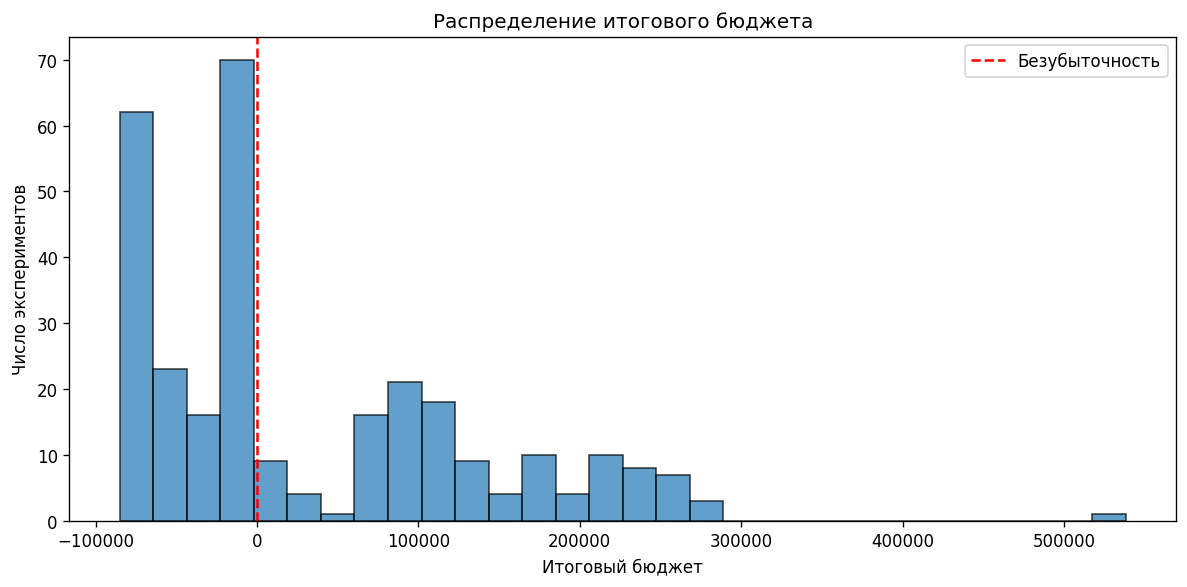

In [6]:
positive = (df['finalBudget'] > 0).sum()
total = len(df)
print(f'Положительный бюджет: {positive}/{total} ({positive/total*100:.1f}%)')
print(f'Отрицательный бюджет: {total - positive}/{total} ({(total-positive)/total*100:.1f}%)')
print(f'Средний итоговый бюджет: {df["finalBudget"].mean():.0f}')
print(f'Медиана итогового бюджета: {df["finalBudget"].median():.0f}')

fig, ax = plt.subplots()
ax.hist(df['finalBudget'], bins=30, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', label='Безубыточность')
ax.set_xlabel('Итоговый бюджет')
ax.set_ylabel('Число экспериментов')
ax.set_title('Распределение итогового бюджета')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Влияние цены билета на бюджет и посещаемость

             avgBudget  avgVisits  avgReview  positivePct
ticketPrice                                              
20            -46430.3     1249.1       10.2          2.0
30            -12813.2     1857.0       21.6         25.0
50            157867.0     4408.2       56.2        100.0


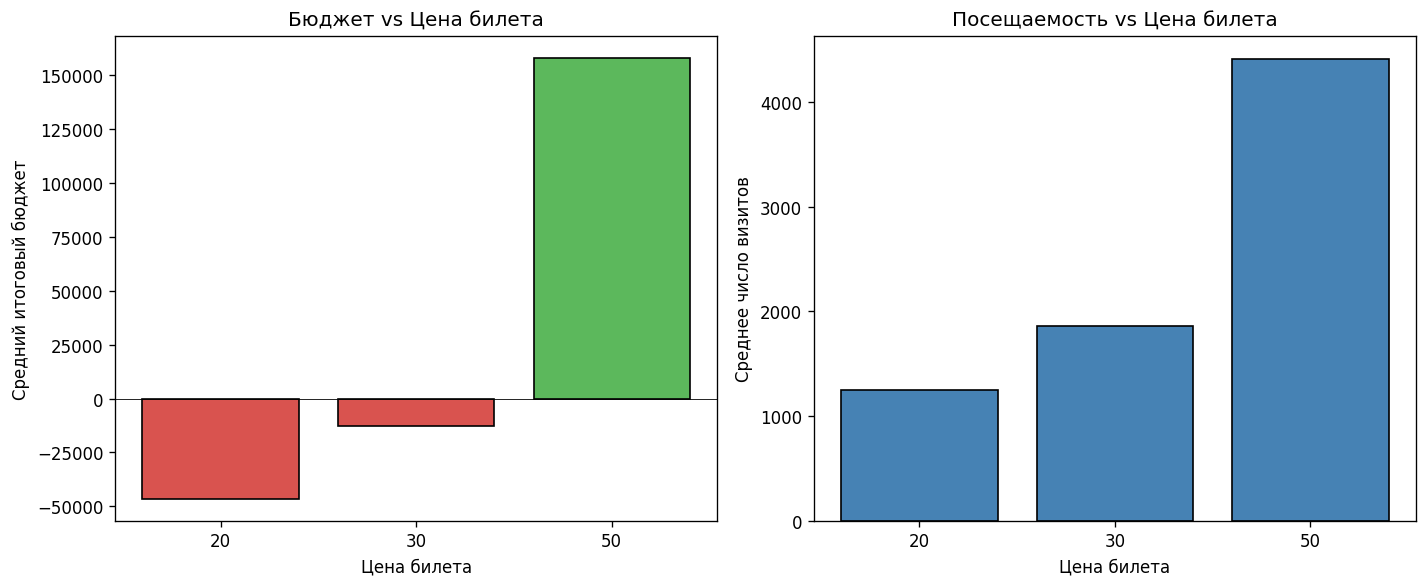

In [7]:
grouped = df.groupby('ticketPrice').agg(
    avgBudget=('finalBudget', 'mean'),
    avgVisits=('totalVisits', 'mean'),
    avgReview=('finalAvgReview', 'mean'),
    positivePct=('finalBudget', lambda x: (x > 0).mean() * 100)
).round(1)
print(grouped)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(grouped.index.astype(str), grouped['avgBudget'], color=['#d9534f' if v < 0 else '#5cb85c' for v in grouped['avgBudget']], edgecolor='black')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Цена билета')
axes[0].set_ylabel('Средний итоговый бюджет')
axes[0].set_title('Бюджет vs Цена билета')

axes[1].bar(grouped.index.astype(str), grouped['avgVisits'], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Цена билета')
axes[1].set_ylabel('Среднее число визитов')
axes[1].set_title('Посещаемость vs Цена билета')

plt.tight_layout()
plt.show()

## 3. Влияние вместимости музея на доход и отказы

                avgBudget  avgVisits  avgRefusals  avgWear
museumCapacity                                            
10                11639.1     2102.7      33483.5     48.5
15                35867.6     2570.3      33017.2     45.6
20                50617.9     2836.3      32751.2     44.5


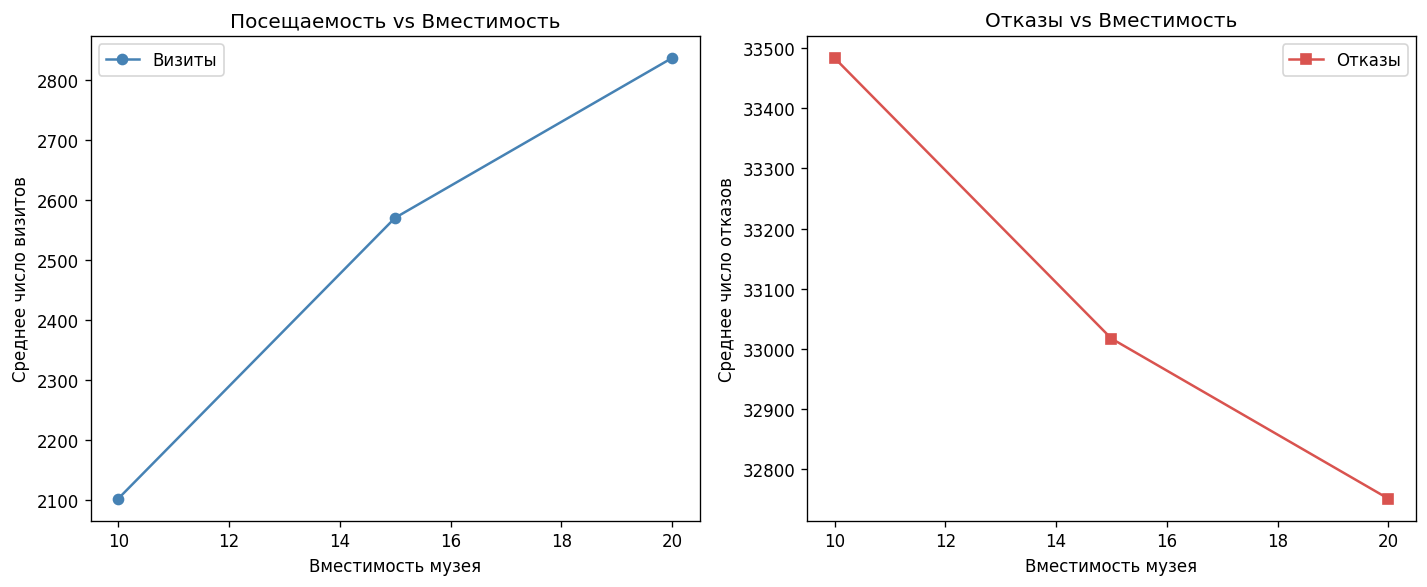

In [8]:
grouped_cap = df.groupby('museumCapacity').agg(
    avgBudget=('finalBudget', 'mean'),
    avgVisits=('totalVisits', 'mean'),
    avgRefusals=('totalRefusals', 'mean'),
    avgWear=('finalWear', 'mean')
).round(1)
print(grouped_cap)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(grouped_cap.index, grouped_cap['avgVisits'], 'o-', label='Визиты', color='steelblue')
axes[0].set_xlabel('Вместимость музея')
axes[0].set_ylabel('Среднее число визитов')
axes[0].set_title('Посещаемость vs Вместимость')
axes[0].legend()

axes[1].plot(grouped_cap.index, grouped_cap['avgRefusals'], 's-', label='Отказы', color='#d9534f')
axes[1].set_xlabel('Вместимость музея')
axes[1].set_ylabel('Среднее число отказов')
axes[1].set_title('Отказы vs Вместимость')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Матрица корреляций ключевых метрик

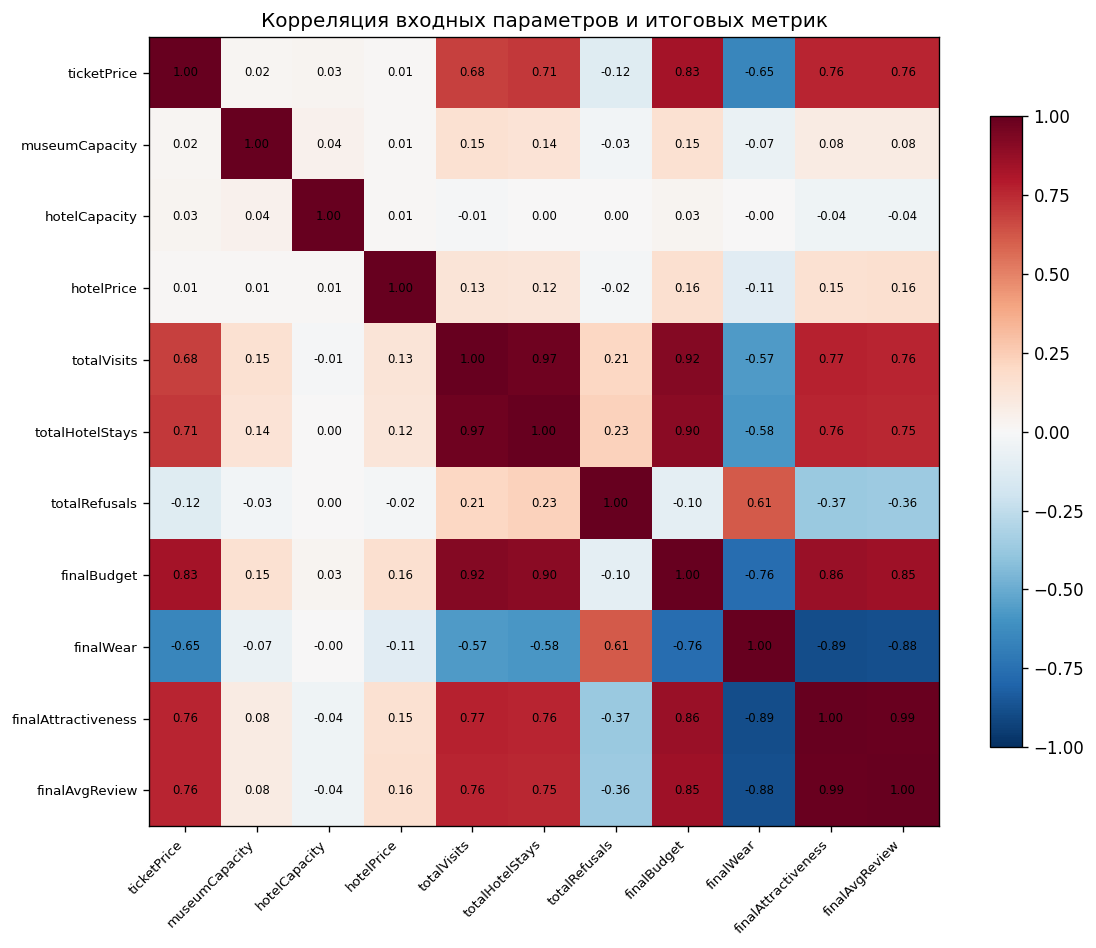

In [9]:
cols = ['ticketPrice', 'museumCapacity', 'hotelCapacity', 'hotelPrice',
        'totalVisits', 'totalHotelStays', 'totalRefusals',
        'finalBudget', 'finalWear', 'finalAttractiveness', 'finalAvgReview']
corr = df[cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(cols, fontsize=8)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Корреляция входных параметров и итоговых метрик')
plt.tight_layout()
plt.show()

## 5. Scatter: Визиты vs Итоговый бюджет (по цене билета)

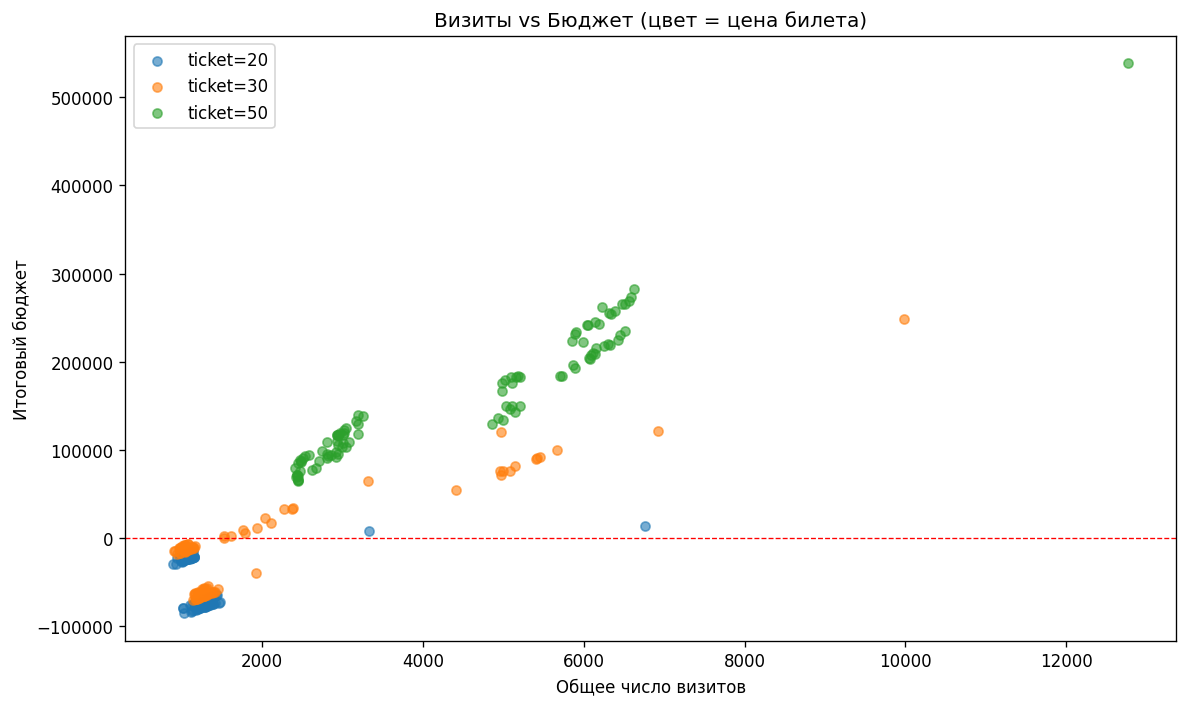

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
for price, grp in df.groupby('ticketPrice'):
    ax.scatter(grp['totalVisits'], grp['finalBudget'], label=f'ticket={price}', alpha=0.6, s=30)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Общее число визитов')
ax.set_ylabel('Итоговый бюджет')
ax.set_title('Визиты vs Бюджет (цвет = цена билета)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Boxplot: итоговый бюджет по комбинации (ticketPrice x hotelPrice)

/var/folders/4j/sxql7z6j007czwcf5zkcl4gh0000gn/T/ipykernel_12760/4188328468.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=combos_sorted, patch_artist=True)


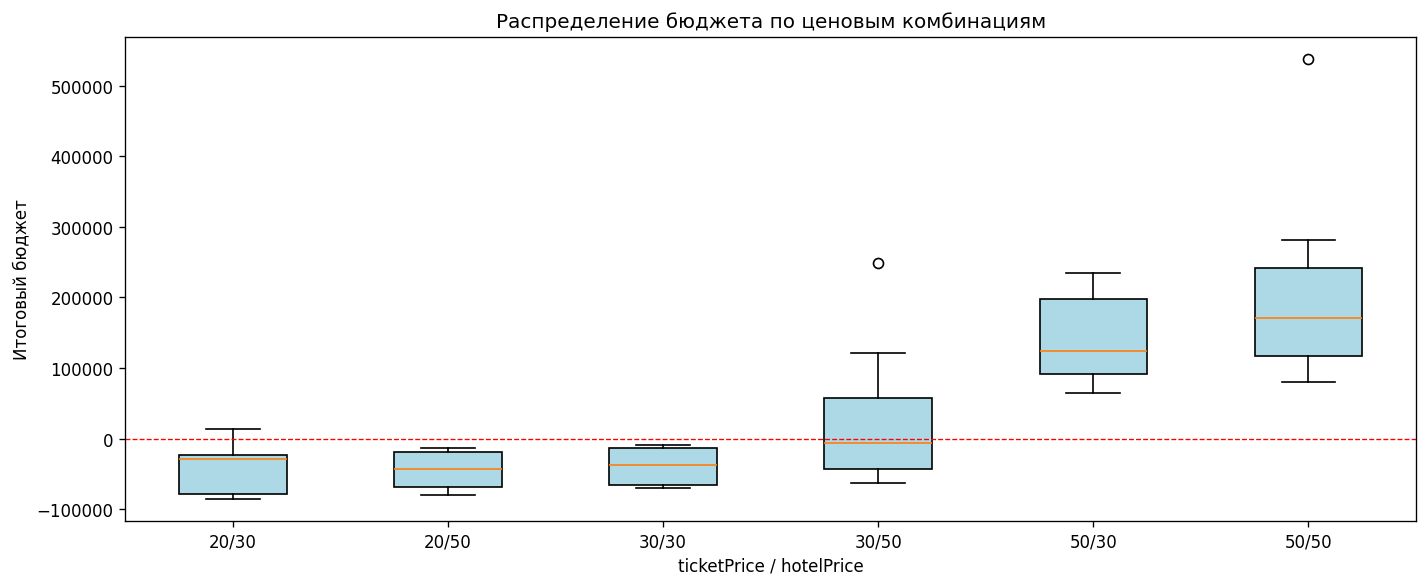

In [11]:
df['price_combo'] = df['ticketPrice'].astype(str) + '/' + df['hotelPrice'].astype(str)
combos_sorted = sorted(df['price_combo'].unique(), key=lambda x: (int(x.split('/')[0]), int(x.split('/')[1])))

fig, ax = plt.subplots(figsize=(12, 5))
data_groups = [df[df['price_combo'] == c]['finalBudget'].values for c in combos_sorted]
bp = ax.boxplot(data_groups, labels=combos_sorted, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('ticketPrice / hotelPrice')
ax.set_ylabel('Итоговый бюджет')
ax.set_title('Распределение бюджета по ценовым комбинациям')
plt.tight_layout()
plt.show()

df.drop(columns=['price_combo'], inplace=True)

## 7. Влияние investMinProb на итоговый бюджет

Параметр `investMinProb` задаёт нижнюю границу вероятности инвестирования менеджером при дефиците «ремонтного фонда» (см. `manager.asl`, приоритет 4). В `results.csv` он записывается около `monthlyExpenditures`.

               avgBudget  medianBudget  avgVisits
investMinProb                                    
0.1              26909.1      -14665.0     2334.4
0.8              30466.7      -11725.0     2428.3


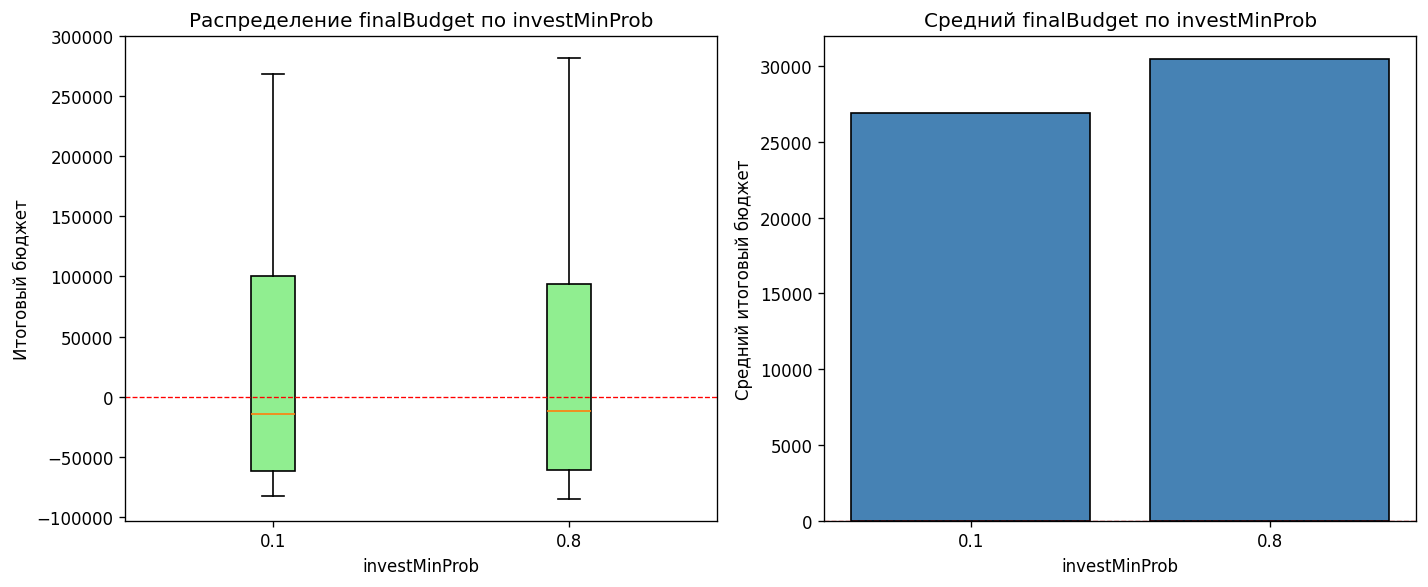

In [12]:
if 'investMinProb' not in df.columns:
    print('Колонка investMinProb отсутствует: перезапустите эксперименты с обновлённым experiment.json и MuseumEnv.')
elif 'isAiPowered' in df.columns:
    df_imp = df[df['isAiPowered'] == 0]
    if df_imp.empty:
        print('Нет строк без ИИ (isAiPowered=0) для анализа investMinProb.')
    else:
        grp_imp = df_imp.groupby('investMinProb').agg(
            avgBudget=('finalBudget', 'mean'),
            medianBudget=('finalBudget', 'median'),
            avgVisits=('totalVisits', 'mean'),
        ).round(1)
        print(grp_imp)

        levels = sorted(df_imp['investMinProb'].unique())
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        data_groups = [df_imp[df_imp['investMinProb'] == v]['finalBudget'].values for v in levels]
        bp = axes[0].boxplot(data_groups, tick_labels=[str(v) for v in levels], patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor('lightgreen')
        axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
        axes[0].set_xlabel('investMinProb')
        axes[0].set_ylabel('Итоговый бюджет')
        axes[0].set_title('Распределение finalBudget по investMinProb')

        axes[1].bar(range(len(levels)), grp_imp['avgBudget'].values, color='steelblue', edgecolor='black')
        axes[1].set_xticks(range(len(levels)))
        axes[1].set_xticklabels([str(v) for v in levels])
        axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)
        axes[1].set_xlabel('investMinProb')
        axes[1].set_ylabel('Средний итоговый бюджет')
        axes[1].set_title('Средний finalBudget по investMinProb')

        plt.tight_layout()
        plt.show()
else:
    grp_imp = df.groupby('investMinProb').agg(
        avgBudget=('finalBudget', 'mean'),
        medianBudget=('finalBudget', 'median'),
        avgVisits=('totalVisits', 'mean'),
    ).round(1)
    print(grp_imp)

    levels = sorted(df['investMinProb'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    data_groups = [df[df['investMinProb'] == v]['finalBudget'].values for v in levels]
    bp = axes[0].boxplot(data_groups, tick_labels=[str(v) for v in levels], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightgreen')
    axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes[0].set_xlabel('investMinProb')
    axes[0].set_ylabel('Итоговый бюджет')
    axes[0].set_title('Распределение finalBudget по investMinProb')

    axes[1].bar(range(len(levels)), grp_imp['avgBudget'].values, color='steelblue', edgecolor='black')
    axes[1].set_xticks(range(len(levels)))
    axes[1].set_xticklabels([str(v) for v in levels])
    axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes[1].set_xlabel('investMinProb')
    axes[1].set_ylabel('Средний итоговый бюджет')
    axes[1].set_title('Средний finalBudget по investMinProb')

    plt.tight_layout()
    plt.show()

## 8. Сравнение: ИИ vs классический менеджер (`isAiPowered`)

Столбец `isAiPowered`: 0 — результаты из `results.csv`, 1 — из `ai_results.csv`. Для ИИ-запусков `investMinProb` заполнен нулём и в сравнении по этому параметру не используется. `finalInfrastructure` — среднее по шести показателям инфраструктуры из CSV.

Сводка по группам (0 = без ИИ, 1 = с ИИ):
            finalWear               finalBudget                       \
                 mean median    std        mean    median        std   
isAiPowered                                                            
0               46.77  39.86  24.42    28687.90  -14110.0  100481.14   
1               26.21  25.46   4.23   172170.62  120655.0  175977.61   

            finalAttractiveness               finalInfrastructure         \
                           mean median    std                mean median   
isAiPowered                                                                
0                         27.83  20.22  23.38               47.90  39.61   
1                         83.60  83.69   3.82               96.69  96.36   

                    
               std  
isAiPowered         
0            16.16  
1             1.96  


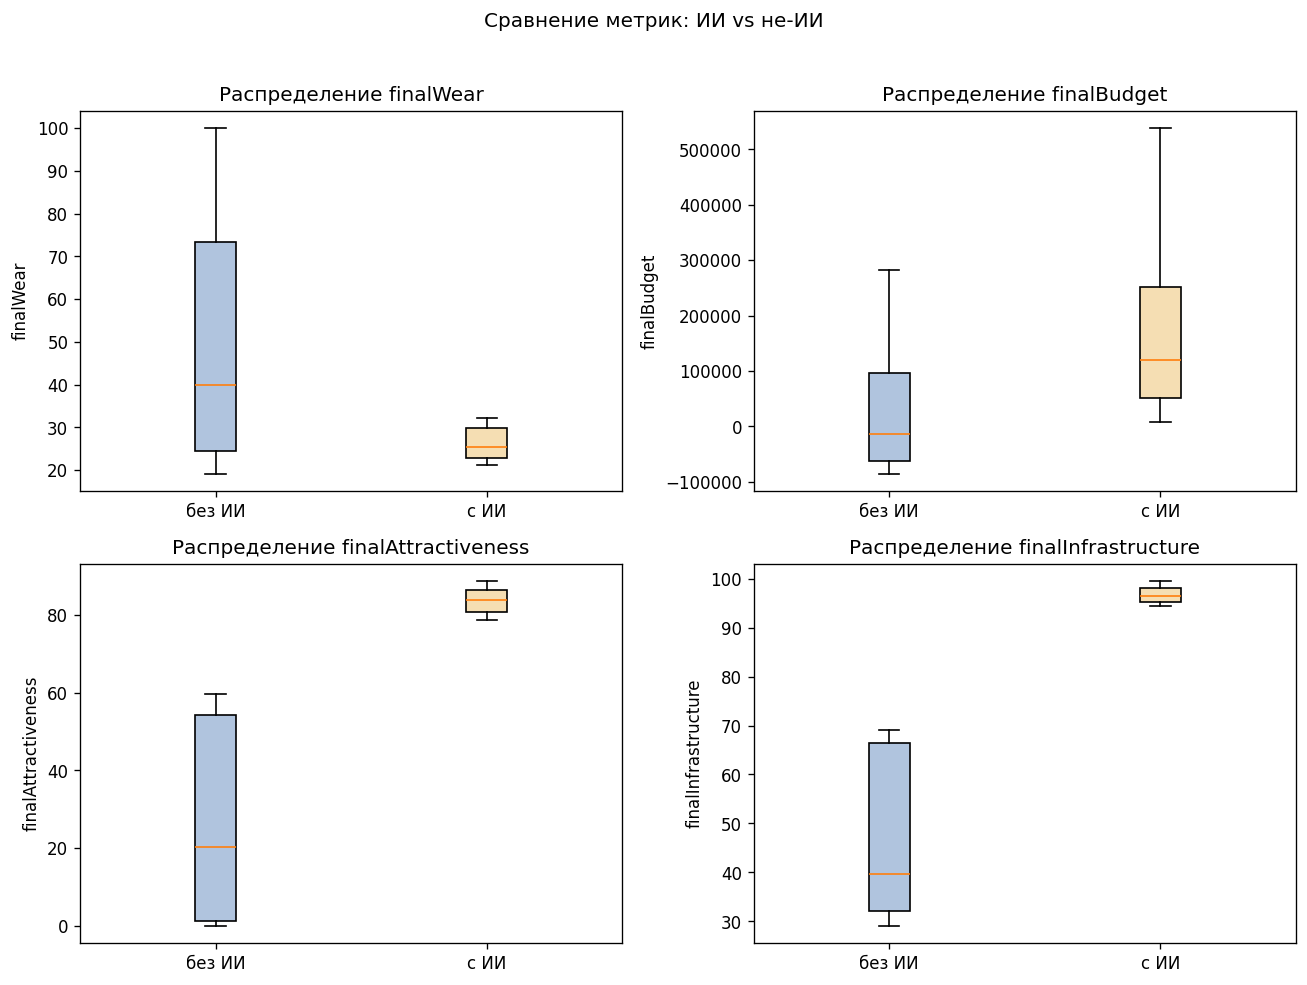

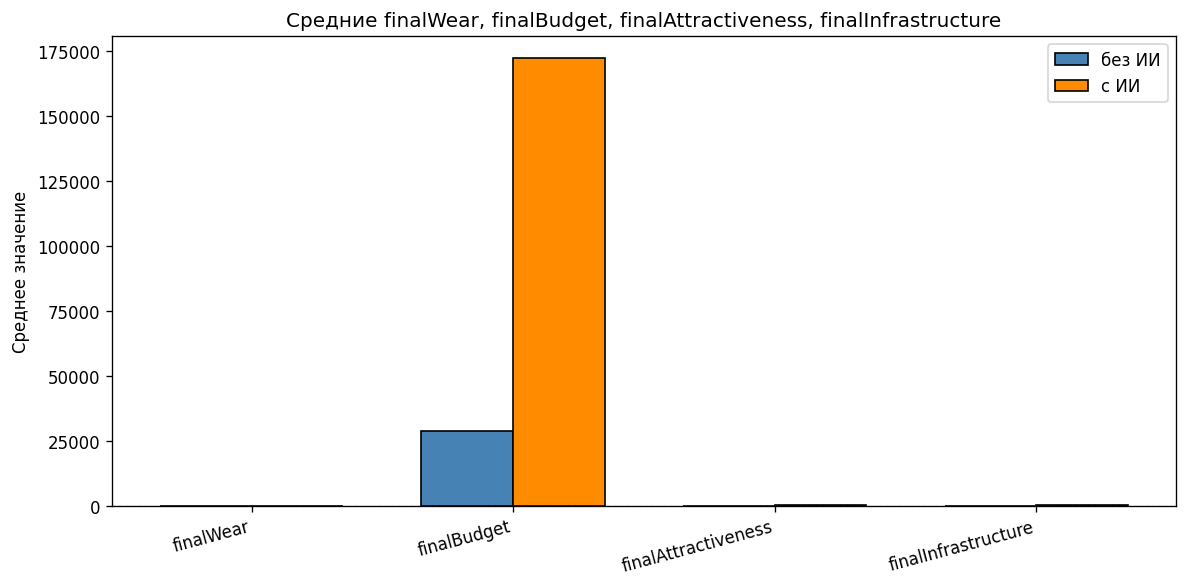

In [13]:
if 'isAiPowered' not in df.columns or df['isAiPowered'].nunique() < 2:
    print('Нужны оба набора: убедитесь, что загружены results.csv и ai_results.csv, и перезапустите первую ячейку.')
else:
    compare_cols = ['finalWear', 'finalBudget', 'finalAttractiveness', 'finalInfrastructure']
    ai_summary = df.groupby('isAiPowered')[compare_cols].agg(['mean', 'median', 'std']).round(2)
    print('Сводка по группам (0 = без ИИ, 1 = с ИИ):')
    print(ai_summary)

    labels = ['без ИИ', 'с ИИ']
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    axes = axes.ravel()
    for ax, col in zip(axes, compare_cols):
        data_groups = [df[df['isAiPowered'] == v][col].values for v in (0, 1)]
        bp = ax.boxplot(data_groups, tick_labels=labels, patch_artist=True)
        for patch, color in zip(bp['boxes'], ['lightsteelblue', 'wheat']):
            patch.set_facecolor(color)
        ax.set_ylabel(col)
        ax.set_title(f'Распределение {col}')
    plt.suptitle('Сравнение метрик: ИИ vs не-ИИ', y=1.02)
    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(10, 5))
    means = df.groupby('isAiPowered')[compare_cols].mean()
    x = range(len(compare_cols))
    w = 0.35
    ax2.bar([i - w / 2 for i in x], means.loc[0], width=w, label='без ИИ', color='steelblue', edgecolor='black')
    ax2.bar([i + w / 2 for i in x], means.loc[1], width=w, label='с ИИ', color='darkorange', edgecolor='black')
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(compare_cols, rotation=15, ha='right')
    ax2.set_ylabel('Среднее значение')
    ax2.set_title('Средние finalWear, finalBudget, finalAttractiveness, finalInfrastructure')
    ax2.legend()
    ax2.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    plt.tight_layout()
    plt.show()